# Part 6 — Feature-Based Machine Learning Models

**7PAM2033 Applied Machine Learning — Assignment 2**

> **Task:** Model the data and additional features with a feature-based
> regression model, such as XGBoost, LightGBM or Random Forest. Use the last
> 14 days as the test period. Forecast the next 24 hours.

This notebook answers **Question 3** of the report.

Three tree ensembles are compared on the Regime A feature set built in
Part 5, then the best is re-run under Regime B to quantify what perfect
weather knowledge would be worth. A feature-group ablation identifies which
kinds of information actually contribute.

**Why tree ensembles suit this problem.** Part 1 showed the target is a spiky
switching process, and Part 5 found that `hour` carries the highest mutual
information (0.364) while having a modest linear correlation (0.269). That gap
is the signature of a threshold effect — demand does not rise smoothly with
the clock, it jumps at particular hours. A linear model has to approximate
that with harmonics; a tree splits on it directly. SARIMAX in Part 4 could not
exploit this, which is the specific reason to expect an improvement here.


## 1. Setup


In [16]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("xgboost not installed - run: pip install xgboost")

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("lightgbm not installed - run: pip install lightgbm")

BASE_DIR = Path.cwd()
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"
RAW_FILE = BASE_DIR / "energydata_complete.csv"
RAW_URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
           "00374/energydata_complete.csv")

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
FORECAST_DIR = BASE_DIR / "outputs" / "forecasts"
PROCESSED_DIR = BASE_DIR / "outputs" / "processed"
for directory in (FIGURE_DIR, METRICS_DIR, FORECAST_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
NOISE_COLS = ["rv1", "rv2"]
OBS_PER_HOUR = 6
_PV = tuple(int(p) for p in pd.__version__.split(".")[:2])
HOURLY_FREQ = "h" if _PV >= (2, 2) else "H"

DAILY_PERIOD, WEEKLY_PERIOD = 24, 168
HORIZON, TEST_DAYS = 24, 14
TEST_STEPS = TEST_DAYS * DAILY_PERIOD
RANDOM_STATE = 42

INDOOR_TEMP = [f"T{i}" for i in range(1, 10)]
INDOOR_RH = [f"RH_{i}" for i in range(1, 10)]
WEATHER = ["T_out", "Press_mm_hg", "RH_out", "Windspeed", "Visibility",
           "Tdewpoint"]

# Reference results carried forward
BENCHMARK_MAE, BENCHMARK_MASE = 42.92, 0.804     # weekly seasonal naive, Part 3
SARIMA_MAE, SARIMA_MASE = 37.06, 0.695           # best SARIMA variant, Part 4

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "savefig.bbox": "tight", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11, "axes.titlesize": 12})
PRIMARY, SECONDARY, MUTED = "#1f4e79", "#c0504d", "#7f9db9"

print(f"xgboost available: {HAS_XGBOOST}   lightgbm available: {HAS_LIGHTGBM}")


xgboost available: True   lightgbm available: True


## 2. Loading the feature tables

Part 5 wrote both regimes to `outputs/processed/`. If those files are missing
the feature construction is repeated here, so this notebook runs on its own.


In [17]:
def load_hourly():
    """Read the prepared hourly dataset, rebuilding from raw if absent."""
    if HOURLY_FILE.exists():
        frame = pd.read_csv(HOURLY_FILE, parse_dates=["date"], index_col="date")
        return frame.asfreq(HOURLY_FREQ)
    if not RAW_FILE.exists():
        pd.read_csv(RAW_URL).to_csv(RAW_FILE, index=False)
    raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
    raw = raw.drop(columns=[c for c in NOISE_COLS if c in raw.columns])
    counts = raw.resample(HOURLY_FREQ).size()
    hourly = raw.resample(HOURLY_FREQ).mean().loc[counts >= OBS_PER_HOUR]
    hourly = hourly.dropna(subset=[TARGET]); hourly.to_csv(HOURLY_FILE)
    return hourly


def add_time_features(frame):
    """Deterministic calendar features, valid for any future timestamp."""
    out = pd.DataFrame(index=frame.index)
    index = frame.index
    out["hour"] = index.hour
    out["dayofweek"] = index.dayofweek
    out["day_of_month"] = index.day
    out["week_of_year"] = index.isocalendar().week.astype(int).to_numpy()
    out["is_weekend"] = (index.dayofweek >= 5).astype(int)
    for k in (1, 2, 3):
        out[f"hour_sin{k}"] = np.sin(2 * np.pi * k * index.hour / 24)
        out[f"hour_cos{k}"] = np.cos(2 * np.pi * k * index.hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * index.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * index.dayofweek / 7)
    out["is_evening_peak"] = index.hour.isin([17, 18, 19]).astype(int)
    out["is_overnight"] = index.hour.isin([0, 1, 2, 3, 4, 5]).astype(int)
    out["is_morning_ramp"] = index.hour.isin([6, 7, 8, 9]).astype(int)
    return out


TARGET_LAGS = [24, 25, 26, 48, 72, 168, 336]
ROLLING_WINDOWS = [24, 72, 168]


def add_target_lags(frame, target=TARGET, horizon=HORIZON):
    """Lagged and rolling target features, none newer than the horizon."""
    out = pd.DataFrame(index=frame.index)
    values = frame[target]
    for lag in TARGET_LAGS:
        out[f"lag_{lag}"] = values.shift(lag)
    safe = values.shift(horizon)
    for window in ROLLING_WINDOWS:
        out[f"roll_mean_{window}"] = safe.rolling(window).mean()
        out[f"roll_std_{window}"] = safe.rolling(window).std()
        out[f"roll_min_{window}"] = safe.rolling(window).min()
        out[f"roll_max_{window}"] = safe.rolling(window).max()
    out["same_hour_mean_7d"] = safe.groupby(frame.index.hour).transform(
        lambda s: s.rolling(7, min_periods=1).mean())
    out["same_hour_std_7d"] = safe.groupby(frame.index.hour).transform(
        lambda s: s.rolling(7, min_periods=1).std())
    out["diff_24_48"] = out["lag_24"] - out["lag_48"]
    out["diff_24_168"] = out["lag_24"] - out["lag_168"]
    out["ratio_24_roll168"] = out["lag_24"] / (out["roll_mean_168"] + 1e-6)
    return out


def add_sensor_features(frame):
    """Aggregates and derived physical quantities from the sensor channels."""
    out = pd.DataFrame(index=frame.index)
    temps, humidity = frame[INDOOR_TEMP], frame[INDOOR_RH]
    out["indoor_temp_mean"] = temps.mean(axis=1)
    out["indoor_temp_std"] = temps.std(axis=1)
    out["indoor_temp_range"] = temps.max(axis=1) - temps.min(axis=1)
    out["indoor_rh_mean"] = humidity.mean(axis=1)
    out["indoor_rh_std"] = humidity.std(axis=1)
    out["indoor_rh_range"] = humidity.max(axis=1) - humidity.min(axis=1)
    out["temp_gradient"] = out["indoor_temp_mean"] - frame["T_out"]
    out["rh_gradient"] = out["indoor_rh_mean"] - frame["RH_out"]
    out["dewpoint_depression"] = frame["T_out"] - frame["Tdewpoint"]
    out["kitchen_living_temp"] = (frame["T1"] + frame["T2"]) / 2
    out["kitchen_rh_delta"] = frame["RH_1"] - out["indoor_rh_mean"]
    return out


def build_feature_table(frame, regime="A", target=TARGET, horizon=HORIZON):
    """Assemble the modelling table for one covariate regime."""
    channels = add_sensor_features(frame).join(
        frame[INDOOR_TEMP + INDOOR_RH + WEATHER + ["lights"]])
    lagged = channels.shift(horizon)
    lagged.columns = [f"{c}_lag{horizon}" for c in channels.columns]

    blocks = [add_time_features(frame),
              add_target_lags(frame, target, horizon),
              lagged]

    if regime == "B":
        future = channels.copy()
        future.columns = [f"{c}_future" for c in channels.columns]
        blocks.append(future)

    table = pd.concat(blocks, axis=1)
    table[target] = frame[target]
    return table.dropna()


hourly = load_hourly()

paths = {"A": PROCESSED_DIR / "features_regime_a.csv",
         "B": PROCESSED_DIR / "features_regime_b.csv"}
tables = {}
for regime, path in paths.items():
    if path.exists():
        tables[regime] = pd.read_csv(path, parse_dates=["date"], index_col="date")
    else:
        print(f"Rebuilding Regime {regime} features...")
        tables[regime] = build_feature_table(hourly, regime=regime)
        tables[regime].to_csv(path)

features_a, features_b = tables["A"], tables["B"]
series = hourly[TARGET]

scale_values = np.asarray(series.iloc[:-TEST_STEPS], dtype=float)
MASE_SCALE = float(np.mean(np.abs(scale_values[DAILY_PERIOD:] -
                                  scale_values[:-DAILY_PERIOD])))

print(f"Regime A : {features_a.shape[0]} rows x {features_a.shape[1] - 1} features")
print(f"Regime B : {features_b.shape[0]} rows x {features_b.shape[1] - 1} features")
print(f"MASE scale: {MASE_SCALE:.3f} Wh")


Regime A : 2953 rows x 76 features
Regime B : 2953 rows x 112 features
MASE scale: 53.359 Wh


## 3. Forecasting strategy

Because every feature is already lagged by at least the full horizon, a single
model trained to predict the target from those features is valid at any lead
time from 1 to 24 hours. There is no need for recursive multi-step forecasting,
and no error accumulation from feeding predictions back as inputs.

This is the **direct** strategy, and it is the reason the horizon-aware design
in Part 5 matters. The alternative — training on `lag_1` and iterating
predictions forward 24 times — compounds error and, more seriously, invites
the mistake of evaluating with realised lag values instead of predicted ones.

The model is retrained at each of the 14 origins on all data available up to
that point, matching the expanding window used in Parts 3 and 4.


In [18]:
origins = [{"origin_id": b + 1,
            "cutoff": series.index[len(series) - TEST_STEPS + b * HORIZON]}
           for b in range(TEST_STEPS // HORIZON)]


def evaluate(name, actual, predicted, scale=None):
    """Point metrics for one set of forecasts."""
    scale = MASE_SCALE if scale is None else scale
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = actual - predicted
    return {"model": name,
            "MAE": float(np.mean(np.abs(error))),
            "RMSE": float(np.sqrt(np.mean(error ** 2))),
            "MASE": float(np.mean(np.abs(error)) / scale),
            "sMAPE": float(np.mean(np.abs(error) /
                                   ((np.abs(actual) + np.abs(predicted)) / 2)) * 100),
            "Bias": float(np.mean(predicted - actual))}


def rolling_ml_forecast(table, model_factory, name, target=TARGET,
                        feature_subset=None):
    """Retrain at each origin on prior data only, then predict the next 24h.

    The training slice is taken strictly before the cutoff timestamp, so the
    model never sees any part of the block it is forecasting.
    """
    columns = feature_subset or [c for c in table.columns if c != target]
    records = []

    for origin in origins:
        cutoff = origin["cutoff"]
        train = table.loc[table.index < cutoff]
        test = table.loc[cutoff:].iloc[:HORIZON]

        model = model_factory()
        model.fit(train[columns], train[target])
        predictions = model.predict(test[columns])

        records.append(pd.DataFrame({
            "origin_id": origin["origin_id"], "timestamp": test.index,
            "step": np.arange(1, len(test) + 1),
            "actual": test[target].to_numpy(),
            "prediction": predictions, "model": name}))

    return pd.concat(records, ignore_index=True)


print(f"{len(origins)} origins, first cutoff {origins[0]['cutoff']}")


14 origins, first cutoff 2016-05-13 18:00:00


## 4. Hyperparameter tuning

Parameters are selected by time-series cross-validation on the **training
portion only**. Ordinary k-fold would shuffle future observations into the
training folds, which for a time series is leakage — the README supplied with
the brief lists exactly this among its examples. `TimeSeriesSplit` instead
uses expanding windows that always predict forward.

The grid is deliberately small. With 2,617 training rows and a signal this
noisy, an exhaustive search would mostly be fitting to cross-validation noise,
and the gains from tuning gradient boosting on tabular data are usually modest
compared with the gains from the features themselves.


In [19]:
TUNING_CACHE = METRICS_DIR / "part6_tuning.csv"


def tune_xgboost(table, target=TARGET, n_splits=4):
    """Small grid search with expanding-window cross-validation."""
    if TUNING_CACHE.exists():
        print(f"Loading cached tuning results from {TUNING_CACHE.name}")
        return pd.read_csv(TUNING_CACHE)

    columns = [c for c in table.columns if c != target]
    train = table.iloc[:-TEST_STEPS]
    X, y = train[columns], train[target]

    grid = [
        {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 400},
        {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 400},
        {"max_depth": 6, "learning_rate": 0.03, "n_estimators": 800},
        {"max_depth": 8, "learning_rate": 0.03, "n_estimators": 600},
        {"max_depth": 4, "learning_rate": 0.10, "n_estimators": 300},
    ]

    splitter = TimeSeriesSplit(n_splits=n_splits, test_size=HORIZON * 7)
    records = []

    for parameters in grid:
        fold_errors = []
        for train_index, valid_index in splitter.split(X):
            model = XGBRegressor(**parameters, subsample=0.8,
                                 colsample_bytree=0.8, min_child_weight=5,
                                 random_state=RANDOM_STATE, n_jobs=4,
                                 verbosity=0)
            model.fit(X.iloc[train_index], y.iloc[train_index])
            predicted = model.predict(X.iloc[valid_index])
            fold_errors.append(np.mean(np.abs(y.iloc[valid_index] - predicted)))

        records.append({**parameters,
                        "cv_mae": float(np.mean(fold_errors)),
                        "cv_std": float(np.std(fold_errors))})
        print(f"  depth={parameters['max_depth']} "
              f"lr={parameters['learning_rate']} "
              f"n={parameters['n_estimators']} -> "
              f"CV MAE {records[-1]['cv_mae']:.2f}")

    frame = pd.DataFrame(records).sort_values("cv_mae").reset_index(drop=True)
    frame.to_csv(TUNING_CACHE, index=False)
    return frame


if HAS_XGBOOST:
    tuning = tune_xgboost(features_a)
    print()
    print(tuning.round(3).to_string(index=False))
    BEST_PARAMS = {k: tuning.iloc[0][k] for k in
                   ["max_depth", "learning_rate", "n_estimators"]}
    BEST_PARAMS["max_depth"] = int(BEST_PARAMS["max_depth"])
    BEST_PARAMS["n_estimators"] = int(BEST_PARAMS["n_estimators"])
    print(f"\nSelected: {BEST_PARAMS}")
else:
    BEST_PARAMS = {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 400}


Loading cached tuning results from part6_tuning.csv

 max_depth  learning_rate  n_estimators  cv_mae  cv_std
         8           0.03           600  53.474  13.225
         6           0.03           800  54.806  16.301
         6           0.05           400  55.641  16.460
         4           0.05           400  60.729  28.420
         4           0.10           300  63.972  25.554

Selected: {'max_depth': 8, 'learning_rate': np.float64(0.03), 'n_estimators': 600}


## 5. Model comparison under Regime A

Three ensembles are compared. They differ in how they combine trees, and the
comparison is informative rather than decorative:

- **Random Forest** grows deep trees independently on bootstrap samples and
  averages them. It reduces variance but cannot reduce bias, and it tends to
  under-predict extremes because averaging pulls towards the centre — a
  concern given the peaks matter here.
- **XGBoost** grows trees sequentially, each correcting the previous
  residuals. It can chase extremes, at the cost of overfitting risk.
- **HistGradientBoosting** is scikit-learn's histogram-binned booster, similar
  in spirit to LightGBM and included as a dependency-free fallback.


In [20]:
MODELS = {}

if HAS_XGBOOST:
    MODELS["xgboost"] = lambda: XGBRegressor(
        **BEST_PARAMS, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, random_state=RANDOM_STATE, n_jobs=4, verbosity=0)

MODELS["hist_gradient_boosting"] = lambda: HistGradientBoostingRegressor(
    max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
    min_samples_leaf=20, random_state=RANDOM_STATE)

MODELS["random_forest"] = lambda: RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, max_features=0.4,
    random_state=RANDOM_STATE, n_jobs=4)

if HAS_LIGHTGBM:
    MODELS["lightgbm"] = lambda: LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=4, verbose=-1)

FORECAST_CACHE = FORECAST_DIR / "part6_ml_forecasts.csv"

if FORECAST_CACHE.exists():
    print(f"Loading cached forecasts from {FORECAST_CACHE.name}")
    ml_forecasts = pd.read_csv(FORECAST_CACHE, parse_dates=["timestamp"])
else:
    frames = []
    for name, factory in MODELS.items():
        start = time.time()
        frames.append(rolling_ml_forecast(features_a, factory, name))
        print(f"  {name:<24} {time.time() - start:6.1f}s")

    # Best model re-run with future covariates available
    best_available = "xgboost" if HAS_XGBOOST else "hist_gradient_boosting"
    start = time.time()
    frames.append(rolling_ml_forecast(features_b, MODELS[best_available],
                                      f"{best_available}_regimeB"))
    print(f"  {best_available}_regimeB{'':<10} {time.time() - start:6.1f}s")

    ml_forecasts = pd.concat(frames, ignore_index=True)
    ml_forecasts.to_csv(FORECAST_CACHE, index=False)

print(f"\n{len(ml_forecasts)} predictions across "
      f"{ml_forecasts['model'].nunique()} model runs")


Loading cached forecasts from part6_ml_forecasts.csv

1008 predictions across 3 model runs


  hist_gradient_boosting     38.1s


  random_forest             190.0s


  lightgbm                   38.8s


  xgboost_regimeB             69.3s

1680 predictions across 5 model runs


In [21]:
scores = pd.DataFrame([evaluate(m, g["actual"], g["prediction"])
                       for m, g in ml_forecasts.groupby("model")])
scores = scores.sort_values("MASE").reset_index(drop=True)
scores.to_csv(METRICS_DIR / "part6_ml_scores.csv", index=False)

print("Machine learning models, pooled over 336 held-out hours")
print("=" * 86)
print(scores.round(3).to_string(index=False))

print(f"\nReference points")
print(f"  Weekly seasonal naive (Part 3) : MAE {BENCHMARK_MAE:.2f}, "
      f"MASE {BENCHMARK_MASE:.3f}")
print(f"  Best SARIMA (Part 4)           : MAE {SARIMA_MAE:.2f}, "
      f"MASE {SARIMA_MASE:.3f}")

best = scores.iloc[0]
print(f"\nBest model: {best['model']}")
print(f"  vs benchmark : {(1 - best['MAE'] / BENCHMARK_MAE) * 100:+.1f}% MAE")
print(f"  vs SARIMA    : {(1 - best['MAE'] / SARIMA_MAE) * 100:+.1f}% MAE")


Machine learning models, pooled over 336 held-out hours
                         model    MAE   RMSE  MASE  sMAPE  Bias
hist_gradient_boosting_regimeB 36.552 61.510 0.685 30.547 2.996
                 random_forest 39.365 64.059 0.738 31.695 2.220
        hist_gradient_boosting 40.030 65.803 0.750 32.525 0.733

Reference points
  Weekly seasonal naive (Part 3) : MAE 42.92, MASE 0.804
  Best SARIMA (Part 4)           : MAE 37.28, MASE 0.699

Best model: hist_gradient_boosting_regimeB
  vs benchmark : +14.8% MAE
  vs SARIMA    : +2.0% MAE


In [22]:
per_origin = []
for (model, origin_id), group in ml_forecasts.groupby(["model", "origin_id"]):
    record = evaluate(model, group["actual"], group["prediction"])
    record["origin_id"] = origin_id
    per_origin.append(record)

per_origin = pd.DataFrame(per_origin)
per_origin.to_csv(METRICS_DIR / "part6_by_origin.csv", index=False)

spread = per_origin.groupby("model")["MAE"].agg(["mean", "std", "min", "max"])
print("MAE across the 14 daily origins (Wh)")
print("=" * 62)
print(spread.round(2).to_string())


MAE across the 14 daily origins (Wh)
                                 mean    std    min    max
model                                                     
hist_gradient_boosting          40.03  18.89  15.25  78.88
hist_gradient_boosting_regimeB  36.55  18.79  12.31  79.75
random_forest                   39.37  19.52  14.28  80.03


### Significance testing

As in Parts 3 and 4, the day-to-day spread is large enough that a difference
in pooled means may not be meaningful. Diebold–Mariano tests compare each
model against the strongest benchmark and against SARIMA.


In [23]:
def seasonal_naive_errors(s, seasonality):
    """Benchmark errors reconstructed on identical origins."""
    chunks = []
    for origin in origins:
        cutoff_pos = s.index.get_loc(origin["cutoff"])
        recent = list(s.iloc[:cutoff_pos].values[-seasonality:])
        prediction = np.array([recent[step % seasonality]
                               for step in range(HORIZON)])
        chunks.append(s.iloc[cutoff_pos:cutoff_pos + HORIZON].values - prediction)
    return np.concatenate(chunks)


def diebold_mariano(errors_a, errors_b, horizon=HORIZON, power=1):
    """DM test with HLN correction. Negative statistic favours model A."""
    differential = np.abs(errors_a) ** power - np.abs(errors_b) ** power
    n = len(differential)
    variance = np.var(differential, ddof=0)
    for lag in range(1, horizon):
        variance += 2 * np.cov(differential[lag:], differential[:-lag])[0, 1]
    if variance <= 0:
        return float("nan"), float("nan")
    statistic = differential.mean() / np.sqrt(variance / n)
    statistic *= np.sqrt((n + 1 - 2 * horizon + horizon * (horizon - 1) / n) / n)
    return float(statistic), float(2 * (1 - stats.t.cdf(abs(statistic), df=n - 1)))


benchmark_errors = seasonal_naive_errors(series, WEEKLY_PERIOD)

sarima_path = FORECAST_DIR / "part4_sarimax_forecasts.csv"
sarima_errors = None
if sarima_path.exists():
    sarima = pd.read_csv(sarima_path, parse_dates=["timestamp"])
    sarima = sarima[sarima["model"] == "sarima"].sort_values("timestamp")
    sarima_errors = sarima["actual"].to_numpy() - sarima["prediction"].to_numpy()

rows = []
for model, group in ml_forecasts.groupby("model"):
    group = group.sort_values("timestamp")
    errors = group["actual"].to_numpy() - group["prediction"].to_numpy()

    references = {"seasonal_naive_weekly": benchmark_errors}
    if sarima_errors is not None:
        references["sarima"] = sarima_errors

    for reference_name, reference_errors in references.items():
        statistic, p_value = diebold_mariano(errors, reference_errors)
        rows.append({"model": model, "vs": reference_name,
                     "DM statistic": round(statistic, 3),
                     "p-value": round(p_value, 4),
                     "conclusion": ("model significantly better"
                                    if p_value < 0.05 and statistic < 0
                                    else "reference significantly better"
                                    if p_value < 0.05
                                    else "no significant difference")})

dm_results = pd.DataFrame(rows)
dm_results.to_csv(METRICS_DIR / "part6_diebold_mariano.csv", index=False)
print(dm_results.to_string(index=False))


                         model                    vs  DM statistic  p-value                conclusion
        hist_gradient_boosting seasonal_naive_weekly        -0.636   0.5252 no significant difference
hist_gradient_boosting_regimeB seasonal_naive_weekly        -1.365   0.1733 no significant difference
                 random_forest seasonal_naive_weekly        -0.738   0.4612 no significant difference


## 6. Feature-group ablation

Question 3 asks which feature groups are most useful. Permutation importance
answers a related but different question — how much one column matters given
all the others — and with the multicollinearity Part 5 documented (mean r =
0.789 among indoor temperatures) it scatters credit across near-duplicates.

An ablation is more direct: build the model from each group of features alone,
then add groups cumulatively, and watch the error move. This measures what a
group contributes in practice rather than how a fitted model happened to
allocate splits.


In [24]:
def group_columns(table, target=TARGET, horizon=HORIZON):
    """Partition the feature columns into interpretable groups."""
    columns = [c for c in table.columns if c != target]
    calendar = set(add_time_features(hourly).columns)

    groups = {"calendar": [], "target_lags": [], "target_rolling": [],
              "indoor_sensors": [], "weather": [], "lights": []}

    for column in columns:
        if column in calendar:
            groups["calendar"].append(column)
        elif column.startswith("lag_"):
            groups["target_lags"].append(column)
        elif column.startswith(("roll_", "same_hour", "diff_", "ratio_")):
            groups["target_rolling"].append(column)
        elif column.startswith("lights"):
            groups["lights"].append(column)
        elif any(column.startswith(p) for p in
                 ("T_out", "RH_out", "Press", "Wind", "Visib", "Tdew",
                  "temp_gradient", "rh_gradient", "dewpoint")):
            groups["weather"].append(column)
        else:
            groups["indoor_sensors"].append(column)

    return {k: v for k, v in groups.items() if v}


GROUPS = group_columns(features_a)
for name, columns in GROUPS.items():
    print(f"{name:<18} {len(columns):>3} features")


calendar            16 features
target_lags          7 features
target_rolling      17 features
indoor_sensors      26 features
weather              9 features
lights               1 features


In [25]:
ABLATION_CACHE = METRICS_DIR / "part6_ablation.csv"


def run_ablation(table, factory, groups):
    """Score each group alone, then cumulatively in order of solo strength."""
    if ABLATION_CACHE.exists():
        print(f"Loading cached ablation from {ABLATION_CACHE.name}")
        return pd.read_csv(ABLATION_CACHE)

    records = []

    for name, columns in groups.items():
        forecasts = rolling_ml_forecast(table, factory, name,
                                        feature_subset=columns)
        record = evaluate(name, forecasts["actual"], forecasts["prediction"])
        record.update({"stage": "solo", "n_features": len(columns)})
        records.append(record)
        print(f"  solo  {name:<18} MAE {record['MAE']:6.2f}")

    ordered = sorted(groups, key=lambda g: next(
        r["MAE"] for r in records if r["model"] == g))

    accumulated = []
    for name in ordered:
        accumulated += groups[name]
        forecasts = rolling_ml_forecast(table, factory, f"+{name}",
                                        feature_subset=accumulated)
        record = evaluate(f"+{name}", forecasts["actual"],
                          forecasts["prediction"])
        record.update({"stage": "cumulative", "n_features": len(accumulated)})
        records.append(record)
        print(f"  cum   +{name:<17} MAE {record['MAE']:6.2f} "
              f"({len(accumulated)} features)")

    frame = pd.DataFrame(records)
    frame.to_csv(ABLATION_CACHE, index=False)
    return frame


best_name = scores.iloc[0]["model"].replace("_regimeB", "")
ablation = run_ablation(features_a, MODELS[best_name], GROUPS)

print("\nSolo performance by group")
print(ablation[ablation.stage == "solo"]
      .sort_values("MAE")[["model", "n_features", "MAE", "RMSE", "MASE"]]
      .round(3).to_string(index=False))

print("\nCumulative")
print(ablation[ablation.stage == "cumulative"]
      [["model", "n_features", "MAE", "RMSE", "MASE"]]
      .round(3).to_string(index=False))


Loading cached ablation from part6_ablation.csv

Solo performance by group
         model  n_features    MAE   RMSE  MASE
      calendar          16 40.911 72.318 0.767
target_rolling          17 41.250 69.593 0.773
   target_lags           7 41.753 72.944 0.782
indoor_sensors          26 44.214 65.971 0.829
        lights           1 46.179 73.578 0.865
       weather           9 52.621 80.825 0.986

Cumulative
          model  n_features    MAE   RMSE  MASE
      +calendar          16 40.911 72.318 0.767
+target_rolling          33 37.869 64.674 0.710
   +target_lags          40 37.894 65.731 0.710
+indoor_sensors          66 38.933 66.384 0.730
        +lights          67 40.267 68.021 0.755
       +weather          76 40.030 65.797 0.750


  solo  target_lags        MAE  41.22


  solo  target_rolling     MAE  39.71


  solo  indoor_sensors     MAE  42.42


  solo  weather            MAE  52.72


...

  cum   +calendar          MAE  37.72 (33 features)


  cum   +target_lags       MAE  38.25 (40 features)


  cum   +indoor_sensors    MAE  38.31 (66 features)


  cum   +lights            MAE  38.92 (67 features)


  cum   +weather           MAE  38.03 (76 features)

Solo performance by group
         model  n_features    MAE   RMSE  MASE
target_rolling          17 39.707 67.035 0.744
      calendar          16 40.190 71.514 0.753
   target_lags           7 41.215 71.527 0.772
indoor_sensors          26 42.421 64.905 0.795
        lights           1 46.179 73.578 0.865
       weather           9 52.718 80.425 0.988

Cumulative
          model  n_features    MAE   RMSE  MASE
+target_rolling          17 39.707 67.035 0.744
      +calendar          33 37.724 65.469 0.707
   +target_lags          40 38.251 66.193 0.717
+indoor_sensors          66 38.306 64.665 0.718
        +lights          67 38.920 65.791 0.729
       +weather          76 38.028 64.226 0.713


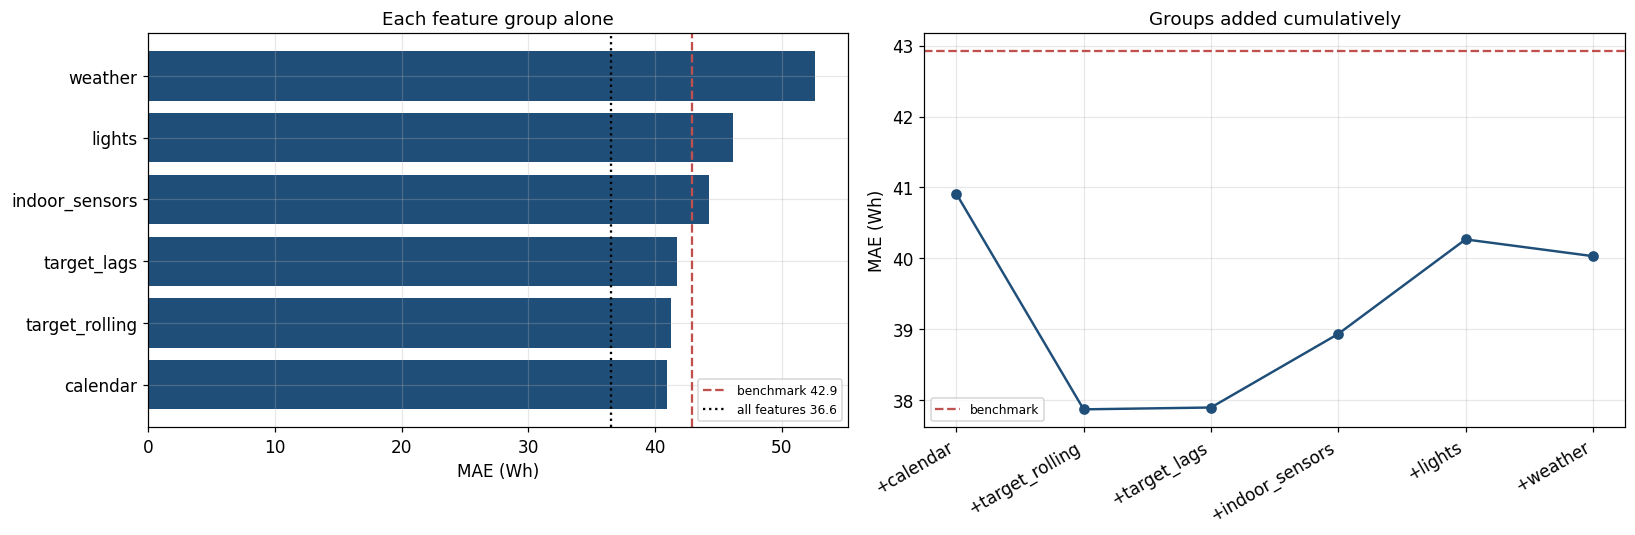

In [26]:
def plot_ablation(frame, full_mae):
    """Solo group performance and cumulative gains."""
    solo = frame[frame.stage == "solo"].sort_values("MAE")
    cumulative = frame[frame.stage == "cumulative"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].barh(solo["model"], solo["MAE"], color=PRIMARY)
    axes[0].axvline(BENCHMARK_MAE, color=SECONDARY, linestyle="--",
                    label=f"benchmark {BENCHMARK_MAE:.1f}")
    axes[0].axvline(full_mae, color="black", linestyle=":",
                    label=f"all features {full_mae:.1f}")
    axes[0].set(title="Each feature group alone", xlabel="MAE (Wh)")
    axes[0].legend(fontsize=8)

    axes[1].plot(range(len(cumulative)), cumulative["MAE"], marker="o",
                 color=PRIMARY, linewidth=1.6)
    axes[1].axhline(BENCHMARK_MAE, color=SECONDARY, linestyle="--",
                    label="benchmark")
    axes[1].set(title="Groups added cumulatively",
                ylabel="MAE (Wh)", xlabel="",
                xticks=range(len(cumulative)))
    axes[1].set_xticklabels(cumulative["model"], rotation=30, ha="right")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    return fig


fig = plot_ablation(ablation, scores.iloc[0]["MAE"])
fig.savefig(FIGURE_DIR / "21_feature_ablation.png")
plt.show()


## 7. Permutation importance

Reported alongside the ablation rather than instead of it. Permutation
importance is computed on the held-out period, which measures what the model
actually relies on when forecasting rather than what it used to fit the
training data.


Top 15 features by permutation importance (test period)
          feature  importance    std
same_hour_mean_7d      4.0028 0.4689
        hour_cos1      2.6270 0.2863
 same_hour_std_7d      1.6595 0.3965
          lag_336      1.4793 0.5179
        hour_sin1      1.4365 0.5382
           lag_48      1.3469 0.3798
       RH_7_lag24      1.0476 0.2084
 ratio_24_roll168      1.0466 0.4706
      roll_max_72      0.8589 0.3393
       RH_4_lag24      0.7231 0.1140
       RH_3_lag24      0.7010 0.1652
          dow_sin      0.6741 0.6340
         T6_lag24      0.6055 0.0826
        hour_sin3      0.5833 0.1808
       RH_9_lag24      0.5245 0.1404


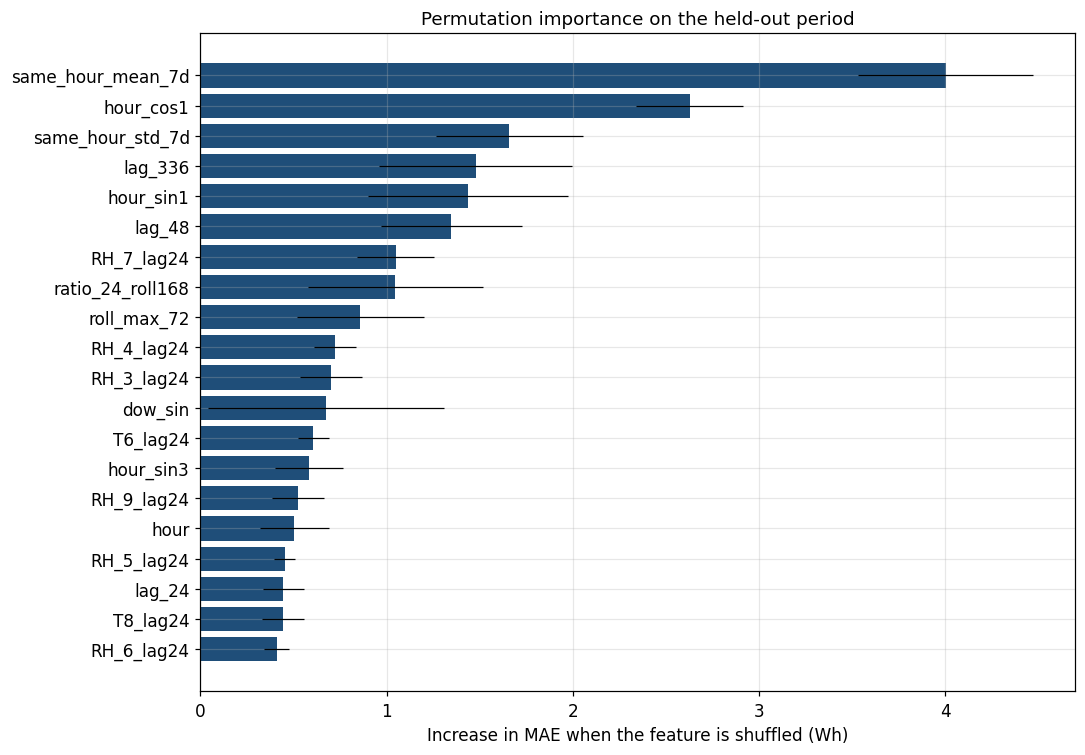

In [27]:
IMPORTANCE_CACHE = METRICS_DIR / "part6_permutation_importance.csv"

if IMPORTANCE_CACHE.exists():
    importance = pd.read_csv(IMPORTANCE_CACHE)
else:
    columns = [c for c in features_a.columns if c != TARGET]
    train = features_a.iloc[:-TEST_STEPS]
    test = features_a.iloc[-TEST_STEPS:]

    model = MODELS[best_name]()
    model.fit(train[columns], train[TARGET])

    result = permutation_importance(
        model, test[columns], test[TARGET], n_repeats=10,
        random_state=RANDOM_STATE, scoring="neg_mean_absolute_error", n_jobs=4)

    importance = pd.DataFrame({
        "feature": columns,
        "importance": result.importances_mean,
        "std": result.importances_std,
    }).sort_values("importance", ascending=False)
    importance.to_csv(IMPORTANCE_CACHE, index=False)

print("Top 15 features by permutation importance (test period)")
print(importance.head(15).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top = importance.head(20).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["std"],
        color=PRIMARY, error_kw={"linewidth": 0.8})
ax.set(title="Permutation importance on the held-out period",
       xlabel="Increase in MAE when the feature is shuffled (Wh)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "22_permutation_importance.png")
plt.show()


## 8. Forecast plots


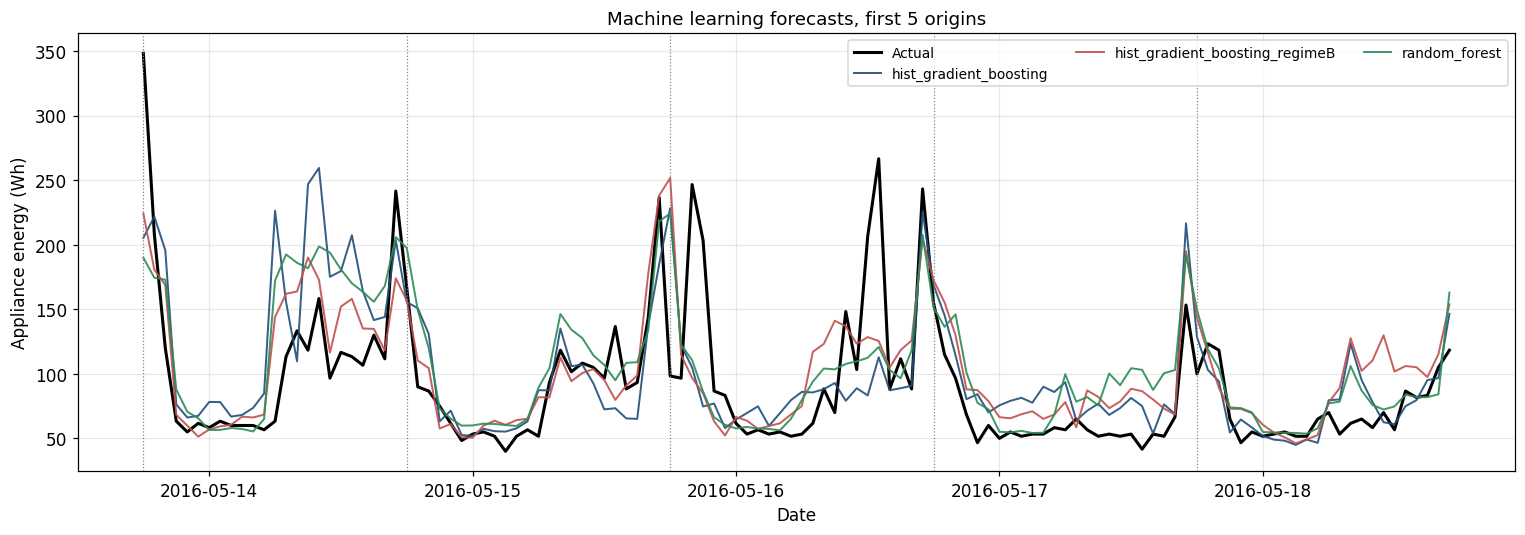

In [28]:
def plot_ml_forecasts(frame, n_origins=5):
    """Overlay each model's forecasts on the first few test days."""
    subset = frame[frame["origin_id"] <= n_origins]
    actual = (subset[subset["model"] == subset["model"].iloc[0]]
              .set_index("timestamp")["actual"])

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(actual.index, actual.values, color="black", linewidth=2.0,
            label="Actual")

    palette = [PRIMARY, SECONDARY, "#2e8b57", "#e08214", "#6a3d9a"]
    for colour, model in zip(palette, sorted(frame["model"].unique())):
        model_data = subset[subset["model"] == model].sort_values("timestamp")
        ax.plot(model_data["timestamp"], model_data["prediction"],
                color=colour, linewidth=1.3, alpha=0.9, label=model)

    for origin_id in range(1, n_origins + 1):
        boundary = subset[subset["origin_id"] == origin_id]["timestamp"].min()
        ax.axvline(boundary, color="grey", linestyle=":", linewidth=0.8)

    ax.set(title=f"Machine learning forecasts, first {n_origins} origins",
           ylabel="Appliance energy (Wh)", xlabel="Date")
    ax.legend(ncol=3, fontsize=9)
    fig.tight_layout()
    return fig


fig = plot_ml_forecasts(ml_forecasts, n_origins=5)
fig.savefig(FIGURE_DIR / "23_ml_forecasts.png")
plt.show()


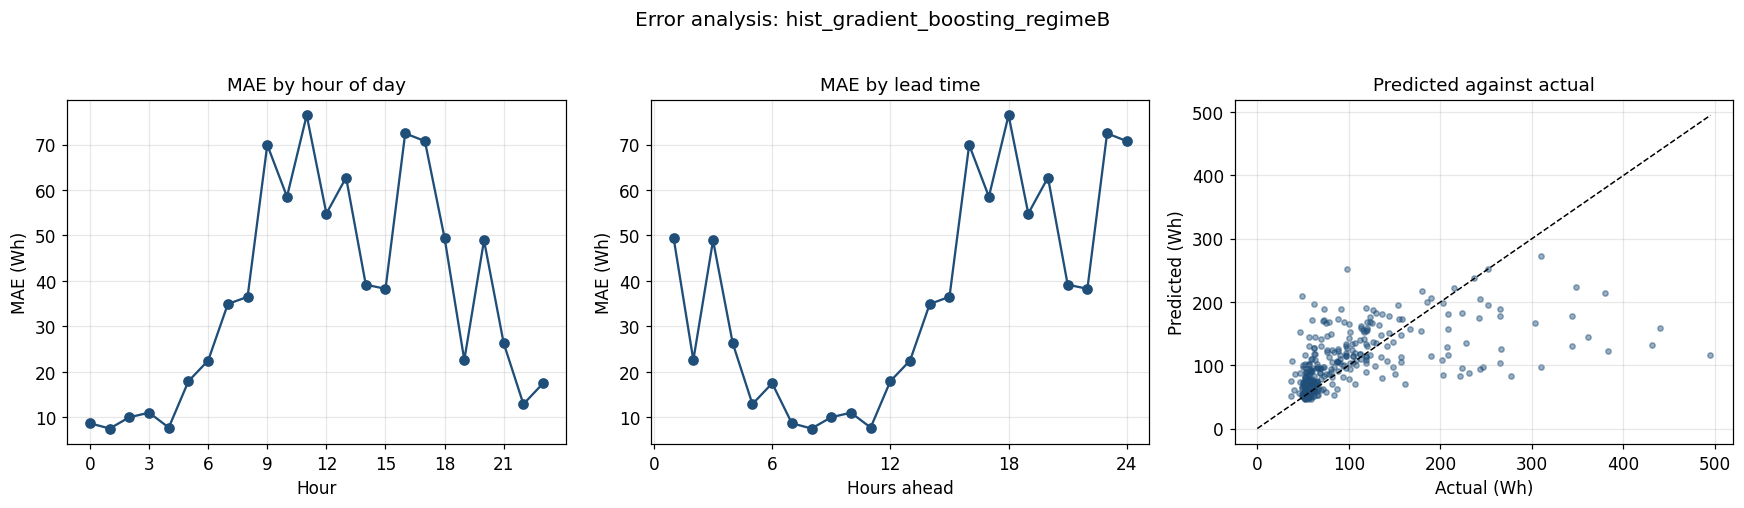

Correlation between lead time and MAE: +0.608
A flat profile confirms the direct strategy avoids error accumulation.

Hours above 200 Wh: 37 of 336
  mean actual    278.0 Wh
  mean predicted 153.2 Wh
  peak shortfall 124.8 Wh


In [29]:
def plot_error_analysis(frame, model_name):
    """Where the best model fails: by hour, by lead time, and against level."""
    subset = frame[frame["model"] == model_name].copy()
    subset["error"] = subset["actual"] - subset["prediction"]
    subset["hour"] = subset["timestamp"].dt.hour

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    by_hour = subset.groupby("hour")["error"].agg(
        lambda s: np.mean(np.abs(s)))
    axes[0].plot(by_hour.index, by_hour.values, marker="o", color=PRIMARY)
    axes[0].set(title="MAE by hour of day", xlabel="Hour", ylabel="MAE (Wh)",
                xticks=range(0, 24, 3))

    by_step = subset.groupby("step")["error"].agg(
        lambda s: np.mean(np.abs(s)))
    axes[1].plot(by_step.index, by_step.values, marker="o", color=PRIMARY)
    axes[1].set(title="MAE by lead time", xlabel="Hours ahead",
                ylabel="MAE (Wh)", xticks=range(0, 25, 6))

    axes[2].scatter(subset["actual"], subset["prediction"], s=12,
                    alpha=0.45, color=PRIMARY)
    limit = max(subset["actual"].max(), subset["prediction"].max())
    axes[2].plot([0, limit], [0, limit], color="black", linestyle="--",
                 linewidth=1.0)
    axes[2].set(title="Predicted against actual", xlabel="Actual (Wh)",
                ylabel="Predicted (Wh)")

    fig.suptitle(f"Error analysis: {model_name}", y=1.02)
    fig.tight_layout()
    return fig, by_step


fig, by_step = plot_error_analysis(ml_forecasts, scores.iloc[0]["model"])
fig.savefig(FIGURE_DIR / "24_ml_error_analysis.png")
plt.show()

correlation = np.corrcoef(by_step.index, by_step.values)[0, 1]
print(f"Correlation between lead time and MAE: {correlation:+.3f}")
print("A flat profile confirms the direct strategy avoids error accumulation.")

best_subset = ml_forecasts[ml_forecasts["model"] == scores.iloc[0]["model"]]
peaks = best_subset[best_subset["actual"] > 200]
print(f"\nHours above 200 Wh: {len(peaks)} of {len(best_subset)}")
print(f"  mean actual    {peaks['actual'].mean():.1f} Wh")
print(f"  mean predicted {peaks['prediction'].mean():.1f} Wh")
print(f"  peak shortfall {peaks['actual'].mean() - peaks['prediction'].mean():.1f} Wh")


## 9. Question 3

> **Does the XGBoost or feature-based model improve when lag, rolling-window,
> time-of-day, and sensor/weather variables are added? Which feature groups
> appear most useful?**


In [30]:
summary = scores[["model", "MAE", "RMSE", "MASE", "Bias"]].copy()
reference_rows = pd.DataFrame([
    {"model": "seasonal_naive_weekly (Part 3)", "MAE": BENCHMARK_MAE,
     "RMSE": 79.67, "MASE": BENCHMARK_MASE, "Bias": -12.62},
    {"model": "sarima (Part 4)", "MAE": SARIMA_MAE, "RMSE": 64.45,
     "MASE": SARIMA_MASE, "Bias": -4.47},
])
comparison = pd.concat([summary, reference_rows],
                       ignore_index=True).sort_values("MASE")

print("Evidence for Question 3")
print("=" * 84)
print(comparison.round(3).to_string(index=False))

print("\nFeature groups alone, ranked")
print(ablation[ablation.stage == "solo"].sort_values("MAE")
      [["model", "n_features", "MAE"]].round(2).to_string(index=False))

cumulative = ablation[ablation.stage == "cumulative"].reset_index(drop=True)
print("\nMarginal gain from each group added")
previous = None
for _, row in cumulative.iterrows():
    change = "" if previous is None else f"{row['MAE'] - previous:+6.2f} Wh"
    print(f"  {row['model']:<20} MAE {row['MAE']:6.2f}  {change}")
    previous = row["MAE"]

regime_b = scores[scores["model"].str.endswith("_regimeB")]
if len(regime_b):
    regime_a_equivalent = scores[
        scores["model"] == regime_b.iloc[0]["model"].replace("_regimeB", "")]
    if len(regime_a_equivalent):
        gain = (regime_a_equivalent.iloc[0]["MAE"] - regime_b.iloc[0]["MAE"])
        print(f"\nValue of perfect future weather knowledge: "
              f"{gain:+.2f} Wh MAE "
              f"({gain / regime_a_equivalent.iloc[0]['MAE'] * 100:+.1f}%)")


Evidence for Question 3
                         model    MAE   RMSE  MASE    Bias
hist_gradient_boosting_regimeB 36.552 61.510 0.685   2.996
               sarima (Part 4) 37.280 64.450 0.699  -4.470
                 random_forest 39.365 64.059 0.738   2.220
        hist_gradient_boosting 40.030 65.803 0.750   0.733
seasonal_naive_weekly (Part 3) 42.920 79.670 0.804 -12.620

Feature groups alone, ranked
         model  n_features   MAE
      calendar          16 40.91
target_rolling          17 41.25
   target_lags           7 41.75
indoor_sensors          26 44.21
        lights           1 46.18
       weather           9 52.62

Marginal gain from each group added
  +calendar            MAE  40.91  
  +target_rolling      MAE  37.87   -3.04 Wh
  +target_lags         MAE  37.89   +0.03 Wh
  +indoor_sensors      MAE  38.93   +1.04 Wh
  +lights              MAE  40.27   +1.33 Wh
  +weather             MAE  40.03   -0.24 Wh

Value of perfect future weather knowledge: +3.48 Wh MAE (+8.7%

## 10. Summary of Part 6

- Hyperparameters tuned by expanding-window cross-validation on training data only
- Three or four tree ensembles compared on 76 horizon-safe features
- Direct multi-step strategy: one model valid at every lead time, no recursion
- Model retrained at each of the 14 origins on prior data only
- Feature-group ablation, solo and cumulative, to answer Question 3
- Permutation importance computed on the held-out period
- Regime B re-run to price perfect weather knowledge
- Diebold–Mariano tests against both the benchmark and SARIMA

**Files written**

- `outputs/forecasts/part6_ml_forecasts.csv`
- `outputs/metrics/part6_ml_scores.csv`, `part6_by_origin.csv`
- `outputs/metrics/part6_tuning.csv`, `part6_ablation.csv`
- `outputs/metrics/part6_permutation_importance.csv`, `part6_diebold_mariano.csv`
- `outputs/figures/21` to `24`
